# 03 — Validación del ETL

El procesamiento ETL se ejecuta via scripts:
```bash
python scripts/prepare_mic.py        # mic fijos → predictions_geo.parquet
python scripts/prepare_mobile.py     # móvil → predictions_mobile.parquet
```
Este notebook valida la calidad del resultado **por trayecto** (no por día):
- **Mic**: trayecto = día de grabación (micrófono fijo)
- **Móvil**: trayecto = `session_id` (cada ruta es independiente; fecha extraída del GPX)

---

### Dos conjuntos de datos — cuándo se usa cada uno

| Variable | Origen | Contenido | Uso |
|---|---|---|---|
| `pred_geo` | `predictions_geo.parquet` | **Solo eventos con GPS asignado** (dataset de producción) | Secciones 1, 2, 4, 5, 6 |
| `pred_all_mic` / `pred_all_mob` | `predictions_mic/mobile.parquet` | **Todas las predicciones** (pre-filtro GPS, incluye audios de prueba) | Solo Sección 3 (calidad del join) |

> Las secciones de análisis de clases, mapas y estadísticas usan **únicamente `pred_geo`**.
> Los audios sin GPS asignado son sesiones de prueba o con fallo GPS y quedan excluidos.

In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

_dp = Path('../data/processed')
for _f in ['predictions_geo.parquet', 'tracks.parquet']:
    if not (_dp / _f).exists():
        raise FileNotFoundError(
            f"{_f} no encontrado.\nEjecutar primero:\n"
            "  python scripts/prepare_mic.py\n"
            "  python scripts/prepare_mobile.py  (opcional)"
        )

pred_geo = pd.read_parquet(_dp / 'predictions_geo.parquet')
tracks   = pd.read_parquet(_dp / 'tracks.parquet')

CLASS_NAMES = {0:"Horn",1:"Siren",2:"Pets",3:"Physiological",
               4:"Speech",5:"Ring Tone",6:"Vibrating",7:"Notifications",8:"Cry"}
pred_geo['class_name'] = pred_geo['class'].map(CLASS_NAMES)

# Columna trayecto: usar la del parquet si ya existe (prepare_mic.py actualizado),
# si no, derivar por compatibilidad con parquets antiguos.
def _trayecto(row):
    if row['source'] == 'mobile' and pd.notna(row.get('session_id')):
        return row['session_id']
    return row['date']

if 'trayecto' not in pred_geo.columns:
    pred_geo['trayecto'] = pred_geo.apply(_trayecto, axis=1)
if 'trayecto' not in tracks.columns:
    tracks['trayecto'] = tracks.apply(_trayecto, axis=1)

print(f"Eventos geolocalizados : {len(pred_geo)}")
print(f"Trackpoints GPS        : {len(tracks)}")
print(f"Fuentes                : {pred_geo['source'].value_counts().to_dict()}")
print(f"Trayectos mic          : {sorted(pred_geo[pred_geo['source']=='mic']['trayecto'].unique())}")
print(f"Trayectos movil        : {sorted(pred_geo[pred_geo['source']=='mobile']['trayecto'].unique()) if 'mobile' in pred_geo['source'].values else []}")

Eventos geolocalizados : 8876
Trackpoints GPS        : 28006
Fuentes                : {'mic': 5009, 'mobile': 3867}
Trayectos mic          : ['ETSE-PAIPORTA_1', 'ETSE-PAIPORTA_2', 'ETSE-PAIPORTA_3', 'ETSE-PAIPORTA_4', 'ETSE-PAIPORTA_5', 'ETSE-PAIPORTA_6', 'PAIPORTA-ETSE_1', 'PAIPORTA-ETSE_2', 'PAIPORTA-ETSE_3', 'PAIPORTA-ETSE_4', 'PAIPORTA-ETSE_5', 'PAIPORTA-ETSE_6']
Trayectos movil        : ['20260523_ida', '20260523_vuelta', 'BURJASOT-SILLA', 'GYM-PAIPORTA', 'MALVARROSA-PAIPORTA', 'MASANASA-SILLA_1', 'MASANASA-SILLA_2_Revisar_GPS', 'PAIPORTA-GYM', 'PAIPORTA-MALVARROSA', 'PAIPORTA-SILLA_1', 'PAIPORTA-SILLA_2', 'SILLA-BURJASOT', 'SILLA-MASANASA_1', 'SILLA-MASANASA_2', 'SILLA-PAIPORTA_1']


## 1. Cobertura de Datos por Trayecto
¿Qué trayectos hay datos, de qué fuente y cuántos eventos?
- Mic: una fila por día de grabación
- Móvil: una fila por sesión (ruta distinta)

source,trayecto,mic,mobile,total
0,20260523_ida,0,71,71
1,20260523_vuelta,0,77,77
2,BURJASOT-SILLA,0,571,571
3,ETSE-PAIPORTA_1,376,0,376
4,ETSE-PAIPORTA_2,807,0,807
5,ETSE-PAIPORTA_3,336,0,336
6,ETSE-PAIPORTA_4,360,0,360
7,ETSE-PAIPORTA_5,271,0,271
8,ETSE-PAIPORTA_6,162,0,162
9,GYM-PAIPORTA,0,180,180


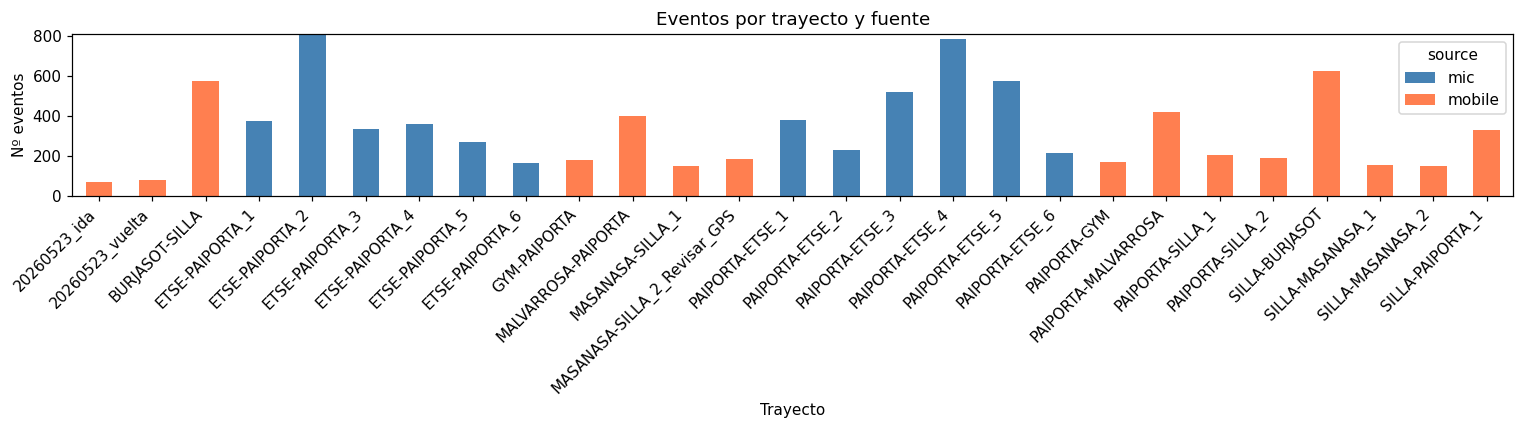

In [9]:
coverage = (
    pred_geo.groupby(['trayecto', 'source'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
coverage['total'] = coverage.drop(columns='trayecto').sum(axis=1)
coverage = coverage.sort_values('trayecto')
display(coverage)

src_cols = [c for c in coverage.columns if c not in ('trayecto', 'total')]
colors = {'mic': 'steelblue', 'mobile': 'coral'}
ax = coverage.set_index('trayecto')[src_cols].plot(
    kind='bar', stacked=True, figsize=(14, 4),
    color=[colors.get(c, 'gray') for c in src_cols],
    title='Eventos por trayecto y fuente'
)
ax.set_xlabel('Trayecto'); ax.set_ylabel('Nº eventos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Validación Temporal — Overlap GPS ↔ Predicciones por Trayecto

Comprueba que las predicciones caen dentro de la ventana temporal del GPS. Hora en **hora local (Europe/Madrid)**.

- `overlap_min ≤ 0` → desincronía audio/GPS
- `pct_geo < 80%` → más del 20% de predicciones de esa fecha sin GPS asignado (fallo de join)
- Columna `fecha` → fecha real del trayecto (mapea PAIPORTA-ETSE_N → día de grabación)

In [ ]:
# Cargar totales pre-join (solo columnas necesarias) para calcular cobertura GPS
_pred_all_mic_s2 = (
    pd.read_parquet(_dp / 'predictions_mic.parquet', columns=['date'])
    if (_dp / 'predictions_mic.parquet').exists() else pd.DataFrame(columns=['date'])
)
_pred_all_mob_s2 = (
    pd.read_parquet(_dp / 'predictions_mobile.parquet', columns=['session_id'])
    if (_dp / 'predictions_mobile.parquet').exists() else pd.DataFrame(columns=['session_id'])
)
_date_totals = _pred_all_mic_s2.groupby('date').size().to_dict()
_sid_totals  = _pred_all_mob_s2.groupby('session_id').size().to_dict() if 'session_id' in _pred_all_mob_s2.columns else {}

results = []
for (trayecto, source), grp in pred_geo.groupby(['trayecto', 'source']):
    # Excluir trayectos sin GPS real (skip / noaudio del ETL)
    if any(s in trayecto for s in ('_skip', '_noaudio')):
        continue

    trk_seg = tracks[tracks['trayecto'] == trayecto]
    if trk_seg.empty:
        continue

    gps_min, gps_max = trk_seg['time'].min(), trk_seg['time'].max()
    pred_min, pred_max = grp['t_start'].min(), grp['t_start'].max()

    overlap   = (min(gps_max, pred_max) - max(gps_min, pred_min)).total_seconds() / 60
    dur_gps   = (gps_max - gps_min).total_seconds() / 60
    fecha_gps = gps_min.tz_convert('Europe/Madrid').strftime('%d-%m-%Y')

    # Cobertura GPS: n geolocalizados / total pre-join para esa fecha/sesión
    if source == 'mic':
        n_total = _date_totals.get(grp['date'].iloc[0], len(grp))
    else:
        n_total = _sid_totals.get(trayecto, len(grp))
    pct_geo = len(grp) / n_total * 100 if n_total > 0 else 0

    label = trayecto + (' ⚠GPS?' if '_Revisar' in trayecto else '')
    results.append({
        'trayecto':    label,
        'fecha':       fecha_gps,
        'source':      source,
        'gps_ini':     gps_min.tz_convert('Europe/Madrid').strftime('%H:%M'),
        'gps_fin':     gps_max.tz_convert('Europe/Madrid').strftime('%H:%M'),
        'dur_gps_min': round(dur_gps, 1),
        'pred_ini':    pred_min.tz_convert('Europe/Madrid').strftime('%H:%M'),
        'pred_fin':    pred_max.tz_convert('Europe/Madrid').strftime('%H:%M'),
        'n_geo':       len(grp),
        'n_total':     n_total,
        'pct_geo':     round(pct_geo, 1),
        'overlap_min': round(overlap, 1),
    })

df_overlap = pd.DataFrame(results)
df_overlap['_date_sort'] = pd.to_datetime(df_overlap['fecha'], format='%d-%m-%Y', errors='coerce')
df_overlap = df_overlap.sort_values(['source', '_date_sort']).drop(columns=['_date_sort'])

def _style_s2(row):
    styles = [''] * len(row)
    cols = row.index.tolist()
    if row['overlap_min'] <= 0 and 'overlap_min' in cols:
        styles[cols.index('overlap_min')] = 'background-color: #ffcccc'
    if 'pct_geo' in cols:
        if row['pct_geo'] < 50:
            styles[cols.index('pct_geo')] = 'background-color: #ffcccc'
        elif row['pct_geo'] < 80:
            styles[cols.index('pct_geo')] = 'background-color: #fff3cd'
    return styles

display(df_overlap.style.apply(_style_s2, axis=1))

bad_overlap  = df_overlap[df_overlap['overlap_min'] <= 0]
bad_coverage = df_overlap[df_overlap['pct_geo'] < 50]

if len(bad_overlap):
    print("\n⚠ Sin solapamiento GPS-predicciones:")
    for _, r in bad_overlap.iterrows():
        print(f"  {r['trayecto']} [{r['fecha']}] — GPS {r['gps_ini']}-{r['gps_fin']} | Pred {r['pred_ini']}-{r['pred_fin']}")
else:
    print("\n✓ Todos los trayectos tienen solapamiento temporal GPS ↔ predicciones.")

if len(bad_coverage):
    print(f"\n⚠ Cobertura GPS baja (<50%) — valorar excluir del análisis:")
    for _, r in bad_coverage.iterrows():
        print(f"  {r['trayecto']} [{r['fecha']}]: {r['pct_geo']:.1f}% ({r['n_geo']}/{r['n_total']})")
else:
    print("\n✓ Todos los trayectos con cobertura GPS ≥ 50%.")

## 3. Calidad del Join — % Geolocalizados por Trayecto

> ⚠️ **Esta sección usa `pred_all_mic` / `pred_all_mob`** (todas las predicciones, pre-filtro GPS)
> para calcular cuántas se perdieron por falta de trackpoint GPS.
> El resto del notebook usa solo `pred_geo` (GPS asignado).

In [ ]:
# Calidad del join: predicciones totales (pre-join, TODAS) vs geolocalizadas (pred_geo, GPS-only)
# pred_all_mic / pred_all_mob = todas las predicciones antes del filtro GPS
# pred_geo = solo eventos con GPS asignado (dataset de producción)

pred_all_mic = pd.read_parquet(_dp / 'predictions_mic.parquet') if (_dp/'predictions_mic.parquet').exists() else pd.DataFrame()
_pred_mob_path = _dp / 'predictions_mobile.parquet'
pred_all_mob = pd.read_parquet(_pred_mob_path) if _pred_mob_path.exists() else pd.DataFrame()

# Resumen global pre/post GPS
total_raw = len(pred_all_mic) + len(pred_all_mob)
total_geo = len(pred_geo)
print(f"=== Pre-filtro GPS (todas las predicciones) ===")
print(f"  Mic   : {len(pred_all_mic)}")
print(f"  Mobile: {len(pred_all_mob)}")
print(f"  Total : {total_raw}")
print(f"\n=== Post-filtro GPS (pred_geo — dataset de producción) ===")
print(f"  Total geolocalizados : {total_geo}  ({total_geo/max(1,total_raw):.1%})")
print(f"  Descartados sin GPS  : {total_raw - total_geo}")
print()

quality = []

# Mic: comparar por DATE — incluye fechas sin GPS (aparecen como 0%)
if not pred_all_mic.empty:
    for date, grp in pred_all_mic.groupby('date'):
        geo_date = pred_geo[(pred_geo['source'] == 'mic') & (pred_geo['date'] == date)]
        total = len(grp)
        joined = len(geo_date)
        traj_list = ', '.join(sorted(geo_date['trayecto'].unique())) if joined else '(sin GPS)'
        quality.append({
            'fecha':          date,
            'trayecto':       traj_list,
            'source':         'mic',
            'total_preds':    total,
            'geolocalizados': joined,
            'descartados':    total - joined,
            'pct':            f"{joined/total*100:.1f}%" if total else "0%",
        })

# Mobile: comparar por session_id
if not pred_all_mob.empty:
    _pred_mob2 = pred_all_mob.rename(columns={'timestamp_onset': 't_start', 'class_id': 'class'})
    _pred_mob2['t_start'] = pd.to_datetime(_pred_mob2['t_start'], utc=True)
    for sid, grp in _pred_mob2.groupby('session_id'):
        geo_sid = pred_geo[(pred_geo['source'] == 'mobile') & (pred_geo['trayecto'] == sid)]
        total = len(grp)
        joined = len(geo_sid)
        quality.append({
            'fecha':          '-',
            'trayecto':       sid,
            'source':         'mobile',
            'total_preds':    total,
            'geolocalizados': joined,
            'descartados':    total - joined,
            'pct':            f"{joined/total*100:.1f}%" if total else "0%",
        })

df_q = pd.DataFrame(quality)

# Ordenar cronológicamente: mic por fecha real, mobile por trayecto
df_q['_sort'] = df_q.apply(
    lambda r: pd.to_datetime(r['fecha'], format='%d-%m-%Y', errors='coerce')
              if r['source'] == 'mic' else pd.NaT,
    axis=1
)
df_q = (
    pd.concat([
        df_q[df_q['source']=='mic'].sort_values('_sort'),
        df_q[df_q['source']=='mobile'].sort_values('trayecto'),
    ])
    .drop(columns=['_sort'])
    .reset_index(drop=True)
)

display(df_q.style.apply(
    lambda col: [
        'background-color: #ffcccc' if float(v.rstrip('%')) < 70 else
        'background-color: #fff3cd' if float(v.rstrip('%')) < 90 else ''
        for v in col
    ] if col.name == 'pct' else ['']*len(col), axis=0
))

mic_geo = pred_geo[pred_geo['source'] == 'mic']
if not mic_geo.empty:
    print("\nEventos mic por microfono (pred_geo):")
    print(mic_geo['microfono_id'].value_counts().to_string())

## 4. Distribución de Clases por Fuente  *(solo `pred_geo` — eventos con GPS)*

Comparación mic vs móvil: ¿detectan las mismas clases con la misma frecuencia?
Los audios de prueba (sin GPS asignado) quedan excluidos.

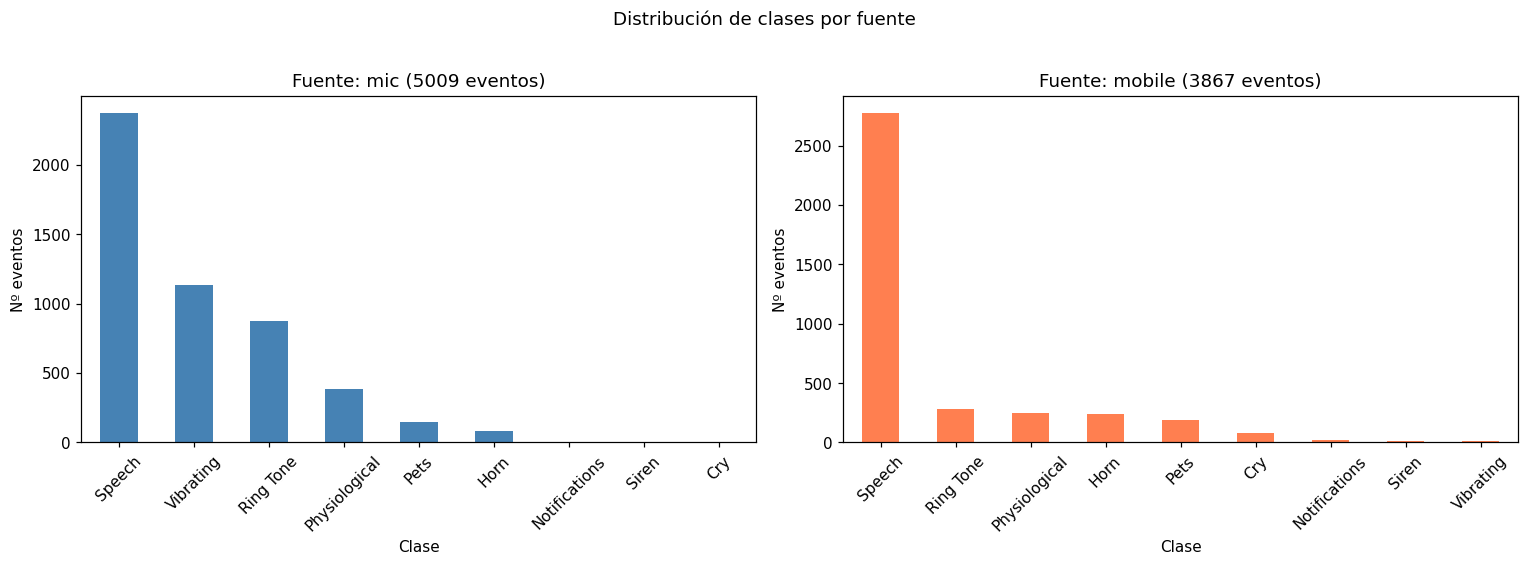

In [12]:
sources = pred_geo['source'].unique()
if len(sources) > 1:
    fig, axes = plt.subplots(1, len(sources), figsize=(14, 5), sharey=False)
    for ax, src in zip(axes, sorted(sources)):
        grp = pred_geo[pred_geo['source'] == src]
        counts = grp['class_name'].value_counts()
        counts.plot(kind='bar', ax=ax, color='steelblue' if src == 'mic' else 'coral')
        ax.set_title(f'Fuente: {src} ({len(grp)} eventos)')
        ax.set_xlabel('Clase'); ax.set_ylabel('Nº eventos')
        ax.tick_params(axis='x', rotation=45)
    plt.suptitle('Distribución de clases por fuente', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    pred_geo['class_name'].value_counts().plot(
        kind='bar', figsize=(10, 4), color='steelblue',
        title=f'Distribución de clases (fuente: {sources[0]})'
    )
    plt.xlabel('Clase'); plt.ylabel('Nº eventos')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 5. Anomalias Conocidas

- **11-03-2026** [mic]: excluido del contador de trayectos (`SKIP_DATES` en `prepare_mic.py`). GPS existe pero sin solapamiento temporal con predicciones (desfase timestamp audio). Trackpoints guardados como `11-03-2026_skip1/2` en `tracks_mic.parquet`.
- **20/22/23/24-04-2026** [mic]: GPX existe pero sin audio procesado en `data/clean/`. Trayectos marcados como `noaudio` en `tracks_mic.parquet`. No aparecen en `predictions_geo.parquet`.
- **Trayectos nombrados Mic**: PAIPORTA-ETSE_1..6 (mañana) y ETSE-PAIPORTA_1..6 (tarde), correspondientes a 23-03-2026 → 16-04-2026.
- **NMS cruzado M1/M2**: `prepare_mic.py` elimina predicciones duplicadas entre microfono frontal y trasero (IoU temporal >= 0.3, ventana +-1s). Reduccion tipica ~17%.

## 6. Distribución de Clases por Trayecto  *(solo `pred_geo` — eventos con GPS)*

Análisis de la distribución cruda (sin umbral de confianza). Permite detectar trayectos con clases inusualmente elevadas o anomalías de clasificación.

> **Nota**: Speech, Vibrating y Ring Tone suelen dominar en grabaciones de vehículo (ruido de motor, radio, conversaciones). Horn y Siren son minoritarios pero son los indicadores de peligro del estudio. El umbral 0.8 en NB02 filtra gran parte del ruido.

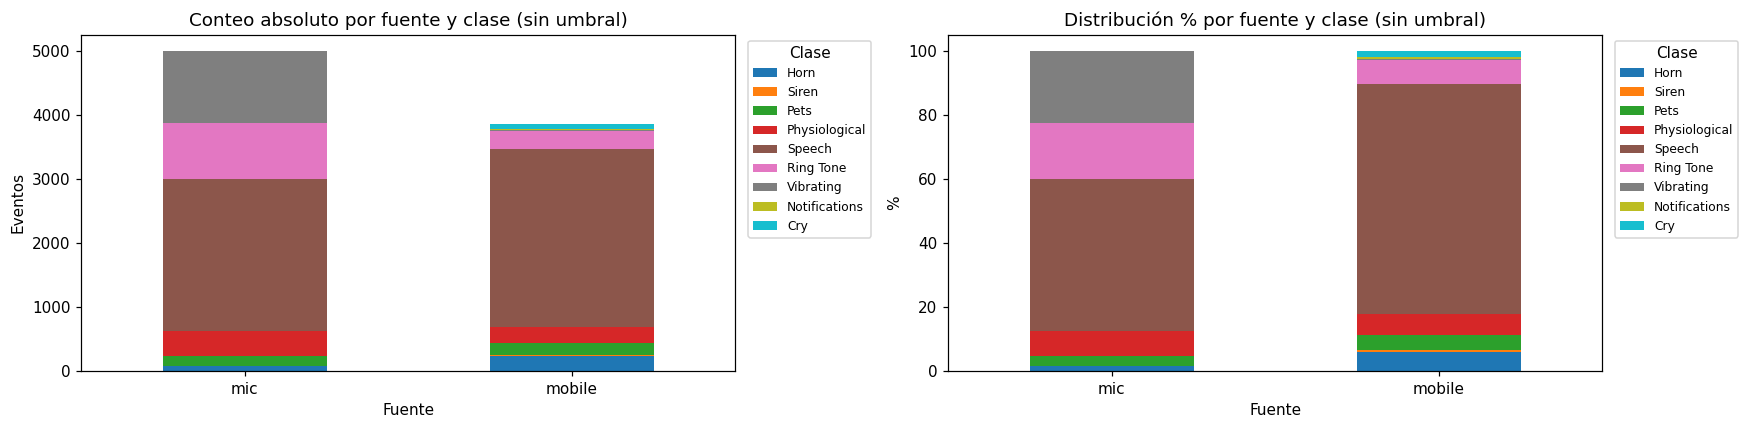

Distribución % (sin umbral):


class_name,Horn,Siren,Pets,Physiological,Speech,Ring Tone,Vibrating,Notifications,Cry
source,,,,,,,,,
mic,1.7,0.1,3.0,7.7,47.4,17.5,22.6,0.1,0.0
mobile,6.1,0.4,4.9,6.5,71.8,7.4,0.4,0.5,2.0


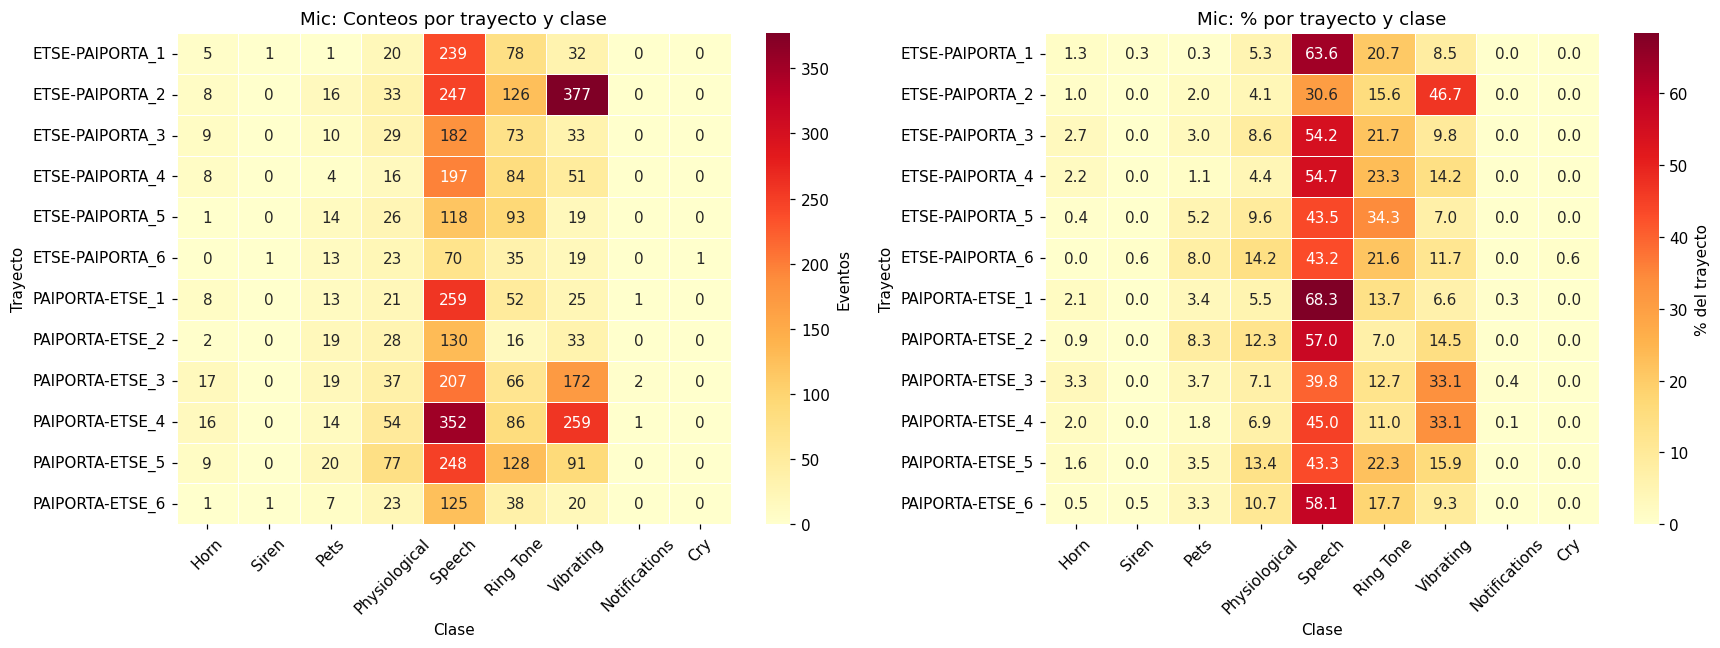

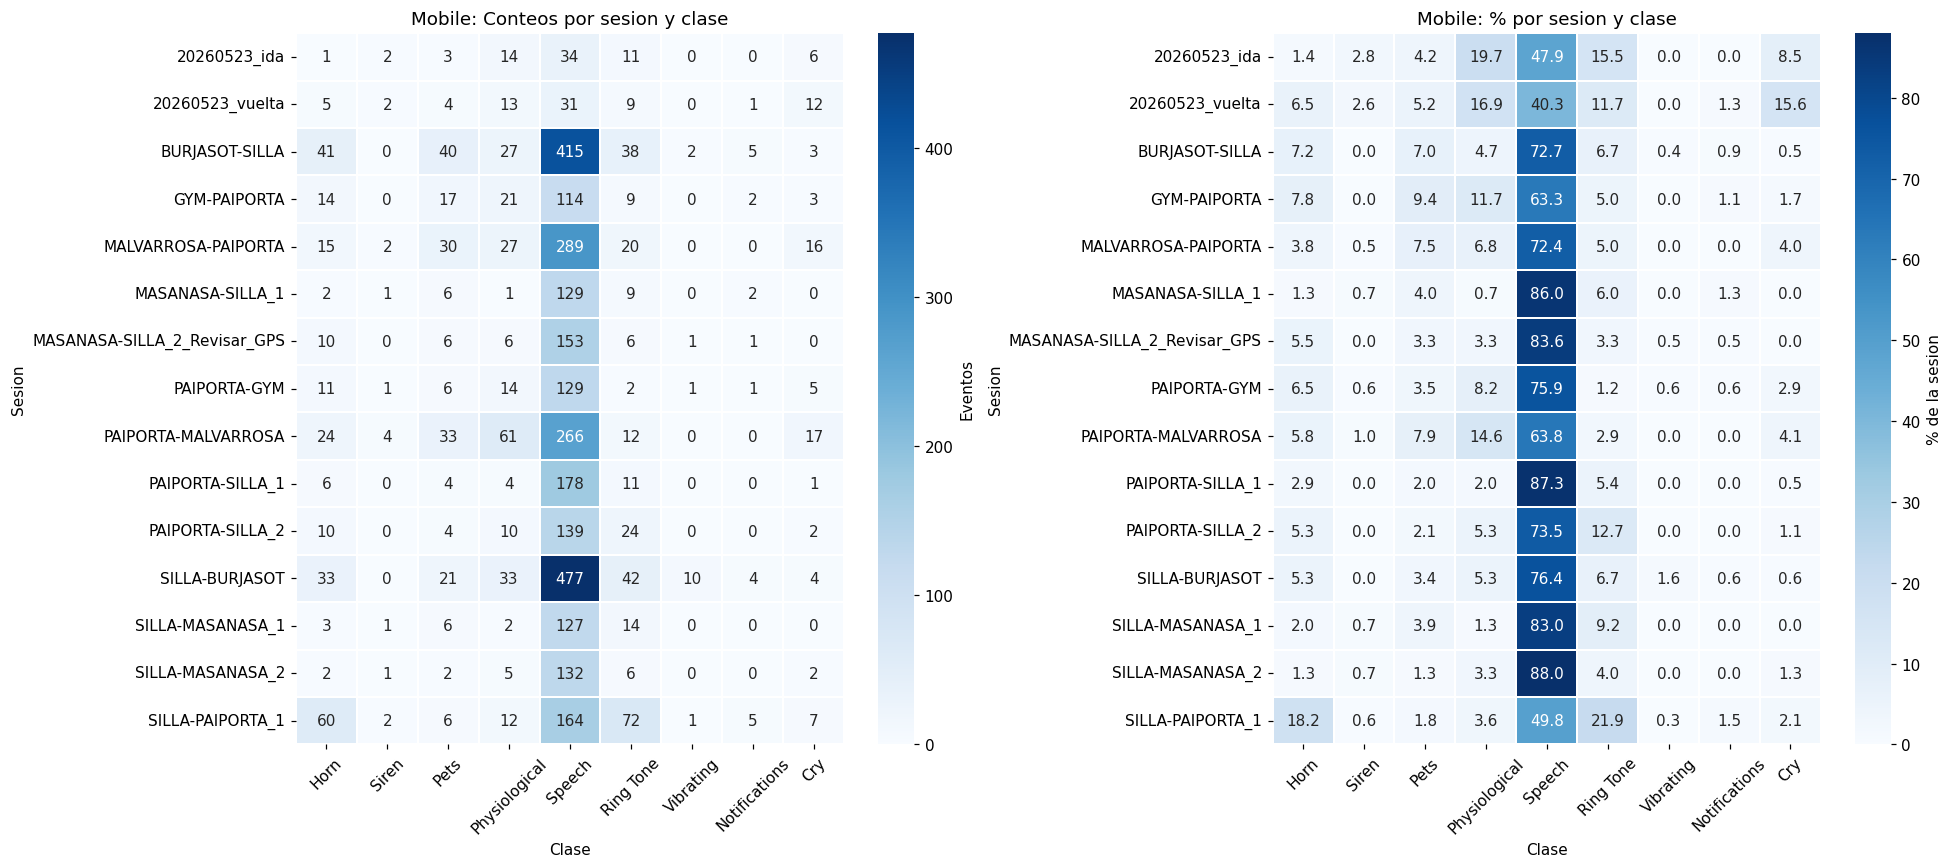


Confianza media por clase y fuente:


conf_media  conf_std     n
source class_name                               
mic    Cry                 0.271       NaN     1
       Horn                0.505     0.193    84
       Notifications       0.446     0.093     4
       Pets                0.421     0.150   150
       Physiological       0.452     0.161   387
       Ring Tone           0.445     0.149   875
       Siren               0.329     0.067     3
       Speech              0.474     0.173  2374
       Vibrating           0.554     0.207  1131
mobile Cry                 0.257     0.145    78
       Horn                0.274     0.192   237
       Notifications       0.302     0.216    21
       Pets                0.263     0.163   188
       Physiological       0.258     0.171   250
       Ring Tone           0.390     0.204   285
       Siren               0.390     0.182    16
       Speech              0.467     0.255  2777
       Vibrating           0.254     0.203    15


Clases con confianza media < 0.3 (posible ruido):


conf_media  conf_std    n
source class_name                              
mic    Cry                 0.271       NaN    1
mobile Cry                 0.257     0.145   78
       Horn                0.274     0.192  237
       Pets                0.263     0.163  188
       Physiological       0.258     0.171  250
       Vibrating           0.254     0.203   15

In [13]:
import seaborn as sns
import numpy as np

CLASS_ORDER = ['Horn', 'Siren', 'Pets', 'Physiological', 'Speech',
               'Ring Tone', 'Vibrating', 'Notifications', 'Cry']

# ── 1. Porcentaje por clase y fuente ─────────────────────────────────────────
pct_src = (
    pred_geo.groupby(['source', 'class_name']).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER, fill_value=0)
)
pct_src_norm = pct_src.div(pct_src.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Conteos absolutos
pct_src.plot(kind='bar', ax=axes[0], colormap='tab10', stacked=True)
axes[0].set_title('Conteo absoluto por fuente y clase (sin umbral)')
axes[0].set_xlabel('Fuente')
axes[0].set_ylabel('Eventos')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Clase', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

# Porcentaje
pct_src_norm.plot(kind='bar', ax=axes[1], colormap='tab10', stacked=True)
axes[1].set_title('Distribución % por fuente y clase (sin umbral)')
axes[1].set_xlabel('Fuente')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Clase', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

print("Distribución % (sin umbral):")
display(pct_src_norm.round(1))

# ── 2. Heatmap trayecto × clase (Mic) — % normalizado por trayecto ───────────
mic_traj = (
    pred_geo[pred_geo['source'] == 'mic']
    .groupby(['trayecto', 'class_name']).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER, fill_value=0)
)
mic_traj_pct = mic_traj.div(mic_traj.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(mic_traj, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Eventos'})
axes[0].set_title('Mic: Conteos por trayecto y clase')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Trayecto')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(mic_traj_pct.round(1), annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '% del trayecto'})
axes[1].set_title('Mic: % por trayecto y clase')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Trayecto')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ── 3. Heatmap trayecto × clase (Mobile) ─────────────────────────────────────
mob_traj = (
    pred_geo[pred_geo['source'] == 'mobile']
    .groupby(['trayecto', 'class_name']).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER, fill_value=0)
)
mob_traj_pct = mob_traj.div(mob_traj.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(mob_traj, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.3, cbar_kws={'label': 'Eventos'})
axes[0].set_title('Mobile: Conteos por sesion y clase')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Sesion')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(mob_traj_pct.round(1), annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            linewidths=0.3, cbar_kws={'label': '% de la sesion'})
axes[1].set_title('Mobile: % por sesion y clase')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Sesion')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ── 4. Confianza media por clase y fuente ─────────────────────────────────────
conf_stats = pred_geo.groupby(['source', 'class_name'])['confidence'].agg(['mean', 'std', 'count']).round(3)
conf_stats.columns = ['conf_media', 'conf_std', 'n']
print("\nConfianza media por clase y fuente:")
display(conf_stats)

# Flag: clases con confianza media baja (<0.3) → probable ruido
low_conf = conf_stats[conf_stats['conf_media'] < 0.3]
if not low_conf.empty:
    print("\nClases con confianza media < 0.3 (posible ruido):")
    display(low_conf)